## Nonlinear dimensionality reduction and visualization

- The development and application of nonlinear dimensionality reduction techniques is also often
referred to as manifold learning, where a manifold refers to a lower dimensional topological space
embedded in a high-dimensional space.

-  These techniques are notoriously hard to use, and with non-ideal hyperparameter
choices, they may cause more harm than good.

### Visualizing data via t-distributed stochastic neighbor embedding
- `t-SNE` learns to embed data points into a lower-dimensional space
such that the pairwise distances in the original space are preserved

In [14]:
import matplotlib.pyplot as plt
import numpy as np

In [9]:
from sklearn.datasets import load_digits

digits = load_digits()
digits.data.shape

(1797, 64)

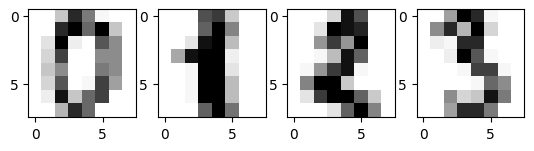

In [ ]:
fig, ax = plt.subplots(1, 4)
for i in range(4):
    ax[i].imshow(digits.images[i], cmap="Greys")
plt.show()

In [10]:
X_digits = digits.data
y_digits = digits.target

In [12]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="pca", random_state=123, n_jobs=-1)
X_digits_tsne = tsne.fit_transform(X_digits)

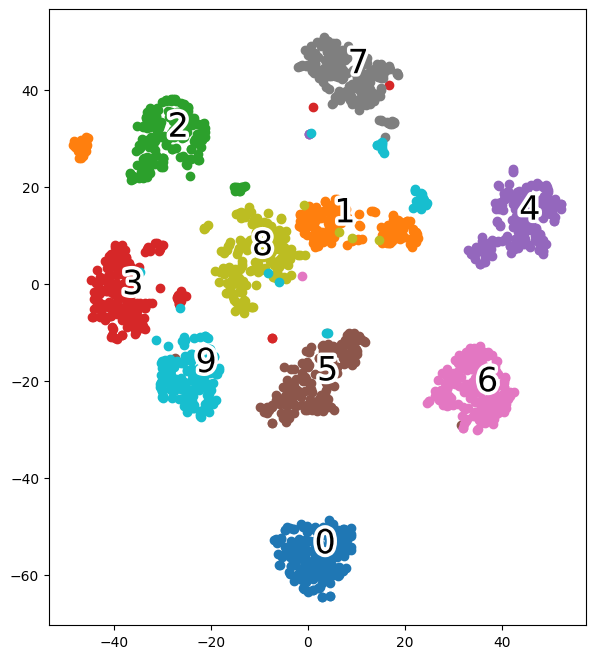

In [ ]:
import matplotlib.patheffects as PathEffects


def plot_projection(x, colors):

    f = plt.figure(figsize=(8, 8))
    ax = plt.subplot(aspect="equal")
    for i in range(10):
        plt.scatter(x[colors == i, 0], x[colors == i, 1])

    for i in range(10):
        xtext, ytext = np.median(x[colors == i, :], axis=0)
        txt = ax.text(xtext, ytext, str(i), fontsize=24)
        txt.set_path_effects(
            [PathEffects.Stroke(linewidth=5, foreground="w"), PathEffects.Normal()]
        )


plot_projection(X_digits_tsne, y_digits)
# plt.savefig('figures/05_13.png', dpi=300)
plt.show()